Using our MVHumanNet dataloader, we can get our cropped images without much hassle.

In this case, we first test on the consistent human case with no random cropping.

In [4]:
%load_ext autoreload
%autoreload 2


In [5]:
# MVHN (from what we did with SEVA)
from dataloader import MVHumanNetDataset
from torch.utils.data import DataLoader

def expand_only_include(only_include):
    if isinstance(only_include, str): # in the format ex: "100001-102000,102020-104000"
        only_include = only_include.split(",")
        expanded_includes = []
        for subrange in only_include:
            start, end = [int(num) for num in subrange.split("-")]
            print(start, end)
            expanded_includes.extend([str(i).zfill(6) for i in range(start, end + 1)])
        return expanded_includes
    else:
        return only_include

dataset = MVHumanNetDataset(
    root_dir="/workspace/datasetvol/mvhuman_data/mv_captures",
    num_images=8,
    step_size=60,
    only_include=expand_only_include("104500-104700"),
    preload_path="/workspace/datasetvol/mvhuman_data/preload_paths/shards/",
    iclight_dataset_path="/workspace/datasetvol/mvhuman_data/relit_images",
    # infu_dataset_path="/workspace/datasetvol/mvhuman_data/inconsistent_images",
    arcface_embeddings_dir="/workspace/datasetvol/mvhuman_data/arcface_embeddings",
    use_sapiens_conditioning=["depth", "seg_masks"],
    random_crop=False,
    maximal_crop=True,
    crop_padding=60,
    use_inconsistent=True,
    random_crop_prob=1.0
)

loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=0)

/root/miniconda3/envs/NoPo-Avatar/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


104500 104700
Detected Arrow dataset at /workspace/datasetvol/mvhuman_data/preload_paths/shards/
Loading Arrow dataset...
Loaded Arrow dataset with 5080 subjects
Pre-loading camera parameters from Arrow dataset...


Indexing Arrow dataset: 100%|██████████| 5080/5080 [00:00<00:00, 7929.50it/s]

Loaded 561 scenes from Arrow dataset
MVHN::init done!


In [6]:
batch = next(iter(loader))

tensor([[True, True, True, True, True, True, True, True]])
tensor([[False, False,  True, False, False, False, False, False]])
torch.Size([8, 3, 576, 576]) torch.Size([8, 1, 576, 576]) torch.Size([8, 1, 576, 576])


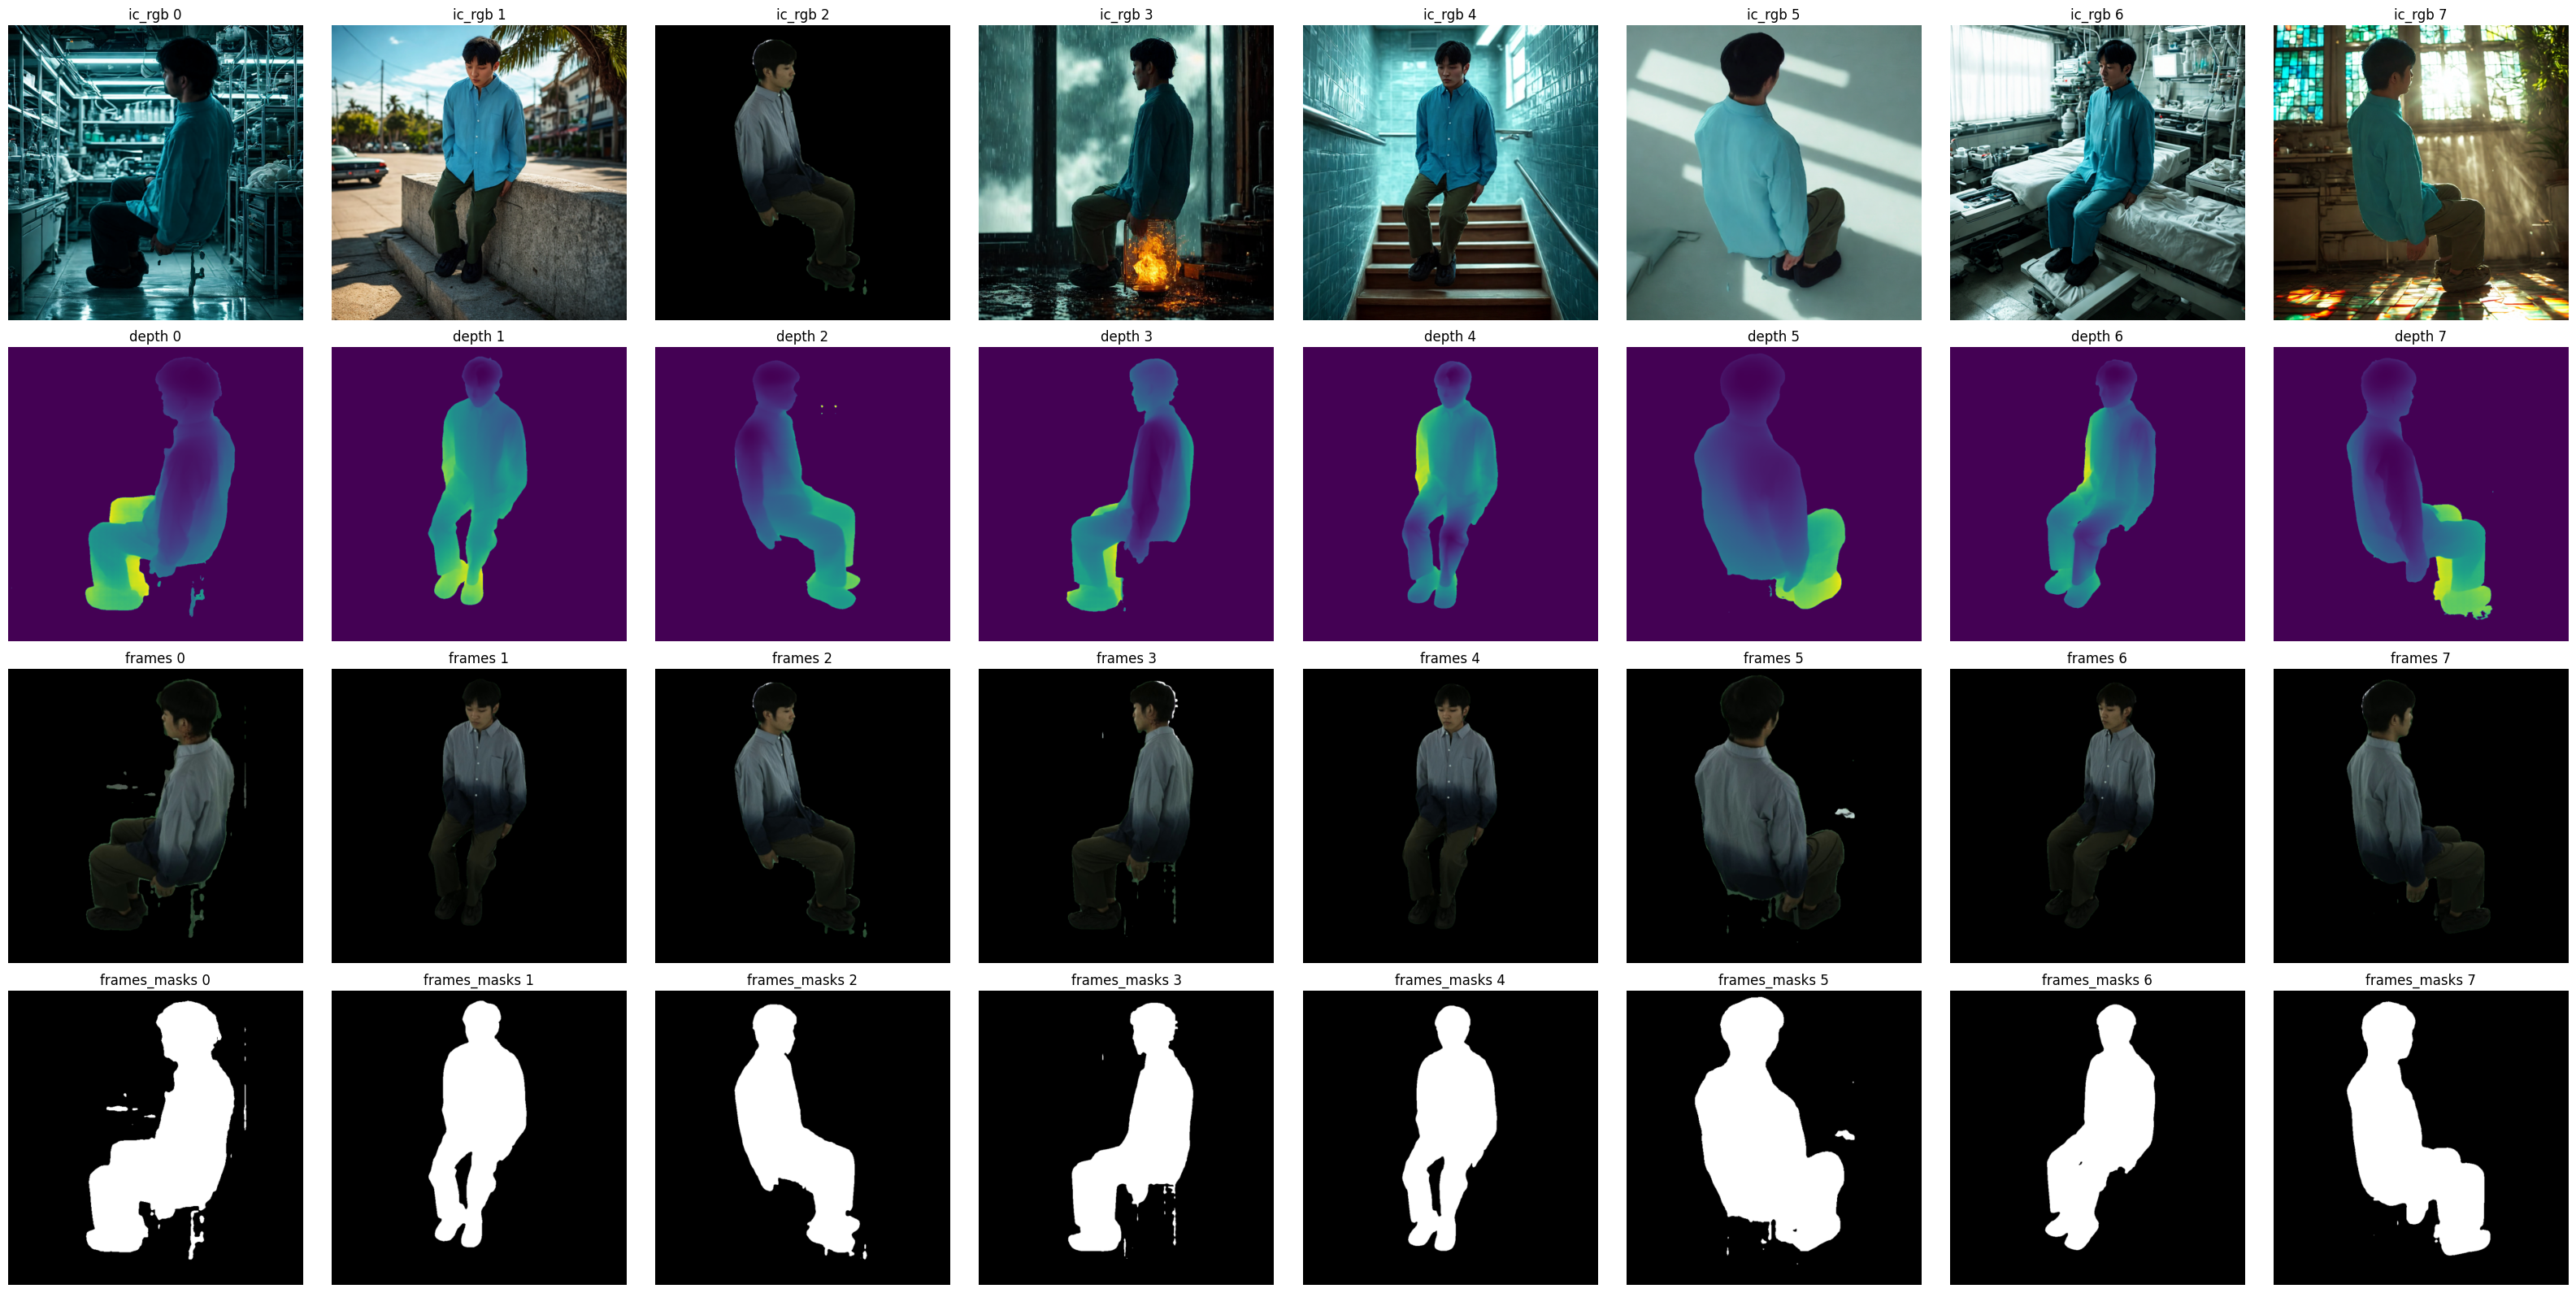

ic_rgb shape: torch.Size([1, 8, 3, 576, 576]), sapiens_conditioning[depth] shape: torch.Size([1, 8, 1, 576, 576]), frames shape: torch.Size([1, 8, 3, 576, 576]), frames_masks shape: torch.Size([1, 8, 1, 576, 576])


In [7]:
# visualize batch data
import matplotlib.pyplot as plt

print(batch['mask'])
print(batch['ref_mask'])

# Prepare images from "ic_rgb", "sapiens_conditioning" ("depth"), "frames", and "frames_masks"
ic_rgb_images = batch["ic_rgb"].squeeze(0).detach().cpu()  # (8, 3, H, W)
sapiens_depth_images = batch["sapiens_conditioning"]["depth"].squeeze(0).detach().cpu()  # (8, 3, H, W)
original_frames = batch["frames"].squeeze(0).detach().cpu()  # (8, 3, H, W)
frames_masks = batch["frames_masks"].squeeze(0).detach().cpu()  # (8, 3, H, W) or (8, 1, H, W); could be 1-chan masks

num_images = ic_rgb_images.shape[0]
print(ic_rgb_images.shape, sapiens_depth_images.shape, frames_masks.shape)
assert sapiens_depth_images.shape[0] == num_images, "Batch size mismatch"
assert frames_masks.shape[0] == num_images, "Frames masks batch size mismatch"

fig, axes = plt.subplots(4, num_images, figsize=(4*num_images, 16))

for i in range(num_images):
    # ic_rgb image
    if batch["ref_mask"][:, i]:
        img_rgb = batch["frames"][:, i, ...].detach().cpu().permute(0, 2, 3, 1).squeeze(0)
    else:
        img_rgb = ic_rgb_images[i].permute(1, 2, 0)

    img_rgb = img_rgb.float()
    img_rgb = img_rgb.clamp(-1, 1)
    img_rgb = (img_rgb + 1) * 0.5
    img_rgb = img_rgb.clamp(0, 1).numpy()
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(f'ic_rgb {i}')
    axes[0, i].axis('off')
    
    # sapiens_conditioning depth image
    img_depth = sapiens_depth_images[i].float().permute(1, 2, 0)
    img_depth = img_depth.clamp(-1, 1)
    img_depth = (img_depth + 1) * 0.5
    img_depth = img_depth.clamp(0, 1).numpy()
    axes[1, i].imshow(img_depth)
    axes[1, i].set_title(f'depth {i}')
    axes[1, i].axis('off')

    # original frames image
    img_frame = original_frames[i].float().permute(1, 2, 0)
    img_frame = img_frame.clamp(-1, 1)
    img_frame = (img_frame + 1) * 0.5
    img_frame = img_frame.clamp(0, 1).numpy()
    axes[2, i].imshow(img_frame)
    axes[2, i].set_title(f'frames {i}')
    axes[2, i].axis('off')

    # frames_masks image
    img_mask = frames_masks[i]
    # If mask is (1, H, W) take channel 0, else assume (3, H, W)
    if img_mask.shape[0] == 1:
        img_mask = img_mask[0]
    elif img_mask.shape[0] == 3:
        img_mask = img_mask.permute(1, 2, 0)
        img_mask = img_mask.float().clamp(0, 1).numpy()
        # Visualize as RGB mask image
        axes[3, i].imshow(img_mask)
    else:
        # Unexpected shape, visualize first channel
        img_mask = img_mask[0]
        axes[3, i].imshow(img_mask.float().clamp(0, 1).numpy(), cmap="gray")
        axes[3, i].set_title(f'frames_masks {i} (unexpected shape)')
        axes[3, i].axis('off')
        continue

    if len(img_mask.shape) == 2:  # single channel mask
        img_mask = img_mask.float().clamp(0, 1).numpy()
        axes[3, i].imshow(img_mask, cmap="gray")
    else:  # RGB mask
        axes[3, i].imshow(img_mask)
    axes[3, i].set_title(f'frames_masks {i}')
    axes[3, i].axis('off')

plt.tight_layout()
plt.show()

print(f"ic_rgb shape: {batch['ic_rgb'].shape}, sapiens_conditioning[depth] shape: {batch['sapiens_conditioning']['depth'].shape}, frames shape: {batch['frames'].shape}, frames_masks shape: {batch['frames_masks'].shape}")

In [17]:
# form an input directory for the nopo inference script
import os
from PIL import Image
import numpy as np

subject_id = batch["subject_id"][0]
timestep = batch["timestep"][0]

input_dir = f"/workspace/NoPo-Avatar/subject_{subject_id}_{timestep}"
os.makedirs(input_dir, exist_ok=True)
os.makedirs(os.path.join(input_dir, "images"), exist_ok=True)
os.makedirs(os.path.join(input_dir, "masks"), exist_ok=True)

num_input_frames = 3
frames_to_choose = np.random.choice(num_images, size=num_input_frames, replace=False)
frames_to_choose = [1, 2, 4] # manual selection
inconsistent_to_use = [0,0,0] # 0 for consistent (MVHN raw), 1 for inconsistent
resize_to = 1024
intrinsics = batch["K"].squeeze(0).numpy()

# copy the images to the input directory
for i in range(min(len(frames_to_choose), num_images)):
    # save RGB image to 'images'
    if inconsistent_to_use[i] == 0:
        img_rgb = batch["frames"][:, frames_to_choose[i], ...].detach().cpu().permute(0, 2, 3, 1).squeeze(0)  # (H, W, 3)
    else:
        img_rgb = batch["ic_rgb"][:, frames_to_choose[i], ...].detach().cpu().permute(0, 2, 3, 1).squeeze(0)  # (H, W, 3)
    orig_shape = img_rgb.shape[:2]
    # de-normalize
    img_rgb = img_rgb.clamp(-1, 1)
    img_rgb = (img_rgb + 1) * 0.5
    img_rgb = img_rgb.clamp(0, 1).numpy()
    # img_rgb is now (H, W, 3) and float32, convert to uint8 for PIL
    img_rgb = (img_rgb * 255).round().astype('uint8')
    img_rgb = Image.fromarray(img_rgb)
    # Resize using PIL Image.resize() method
    img_rgb = img_rgb.resize((resize_to, resize_to), Image.Resampling.LANCZOS)
    img_rgb.save(os.path.join(input_dir, "images", f"{i}.png"))

    # save mask to 'masks'
    img_mask = batch["frames_masks"][:, frames_to_choose[i], ...].detach().cpu().squeeze(0)  # (1, H, W) or (H, W)
    # Handle single channel mask - squeeze channel dimension if present
    if len(img_mask.shape) == 3 and img_mask.shape[0] == 1:
        img_mask = img_mask.squeeze(0)  # (H, W) for grayscale
    elif len(img_mask.shape) == 3 and img_mask.shape[0] == 3:
        img_mask = img_mask.permute(1, 2, 0)  # (H, W, 3) for RGB
    # img_mask is now (H, W) for grayscale or (H, W, 3) for RGB
    img_mask = img_mask.clamp(0, 1).numpy()
    img_mask = (img_mask * 255).round().astype('uint8')
    # Use 'L' mode for grayscale (single channel), 'RGB' for 3 channels
    mode = 'L' if len(img_mask.shape) == 2 else 'RGB'
    img_mask = Image.fromarray(img_mask, mode=mode)
    # Resize using PIL Image.resize() method (use NEAREST for masks to preserve binary values)
    img_mask = img_mask.resize((resize_to, resize_to), Image.Resampling.NEAREST)
    img_mask.save(os.path.join(input_dir, "masks", f"{i}.png"))
    intrinsics[i] = intrinsics[frames_to_choose[i]] * (resize_to / orig_shape[0])

np.save(os.path.join(input_dir, "intrinsics.npy"), intrinsics)

print(f"Input directory created at {input_dir}")

Input directory created at /workspace/NoPo-Avatar/subject_104529_0305


In [19]:
# call the inference script
!python nopo_inference.py --input {input_dir} --output {input_dir}_output

NoPo-Avatar: Feedforward Pose-Free Inference
Input directory: /workspace/NoPo-Avatar/subject_104529_0305
Checkpoint: /workspace/NoPo-Avatar/checkpoint/thuman2.1_huge100k_inputs3_res1024_iter90000.ckpt
Output: /workspace/NoPo-Avatar/subject_104529_0305_output
Use masks: True
Using device: cuda
Image size: (1024, 1024)
Using masks: True

Loading images and masks from /workspace/NoPo-Avatar/subject_104529_0305...
Found 3 images in /workspace/NoPo-Avatar/subject_104529_0305/images
Loaded masks from /workspace/NoPo-Avatar/subject_104529_0305/masks
Loaded 3 images: 0.png, 1.png, 2.png
Loading checkpoint from /workspace/NoPo-Avatar/checkpoint/thuman2.1_huge100k_inputs3_res1024_iter90000.ckpt
/workspace/NoPo-Avatar/nopo_inference.py:420: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https:/

In [15]:
# visualize the output
!python visualize_gaussians.py --input {input_dir}_output/gaussians.npz --output {input_dir}_output_viz

Loading /workspace/NoPo-Avatar/subject_104529_0305_output/gaussians.npz...
Loaded 1,284,263 Gaussians

Gaussian Statistics
Number of Gaussians: 1,284,263

Positions (means):
  Range X: [-1.003, 0.899]
  Range Y: [-1.427, 0.477]
  Range Z: [-0.214, 0.215]

Opacities:
  Mean: 0.054
  Std: 0.083
  Range: [0.000, 0.793]
  Visible (>0.5): 1,289 (0.1%)

Scales:
  Mean: 0.0048
  Std: 0.0053
  Range: [0.0003, 0.0382]

Converting covariances to quaternions and scales...
Converting harmonics to RGB...
Saving 1284263 Gaussians to /workspace/NoPo-Avatar/subject_104529_0305_output_viz/gaussians.ply...
✓ Saved PLY to /workspace/NoPo-Avatar/subject_104529_0305_output_viz/gaussians.ply
Creating 3D visualization...
✓ Saved plot to /workspace/NoPo-Avatar/subject_104529_0305_output_viz/gaussians_3d.png
Figure(1200x1000)

Visualization Complete!

To view your Gaussian splat:
1. Go to https://antimatter15.com/splat/
2. Drag and drop: /workspace/NoPo-Avatar/subject_104529_0305_output_viz/gaussians.ply
3. Na